#📌 Extracción

In [1]:
# Importar las librerías necesarias
import pandas as pd
import requests
from io import StringIO

raw_url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# 1. Obtener los datos de la URL
print(f"Descargando datos desde: {raw_url}")
respuesta = requests.get(raw_url)

# Verificar que la descarga fue exitosa
if respuesta.status_code == 200:
    print("✅ Datos descargados correctamente.")
else:
    print(f"❌ Error al descargar los datos. Código de estado: {respuesta.status_code}")

# 2. Convertir el contenido JSON a un DataFrame de Pandas
datos_json = respuesta.json()

# normalizar a DataFrame
df_telecom = pd.json_normalize(datos_json)

print("\n✅ Datos convertidos a DataFrame.")
print(f"Shape del DataFrame: {df_telecom.shape}")
print("\nPrimeras 5 filas:")
df_telecom.head()

Descargando datos desde: https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json
✅ Datos descargados correctamente.

✅ Datos convertidos a DataFrame.
Shape del DataFrame: (7267, 21)

Primeras 5 filas:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [2]:
# Ver información completa del DataFrame
print("=== INFORMACIÓN DEL DATASET ===\n")
df_telecom.info()

print("\n=== TIPOS DE DATOS POR COLUMNA ===\n")
print(df_telecom.dtypes)

print("\n=== PRIMERAS 5 FILAS ===\n")
df_telecom.head()

=== INFORMACIÓN DEL DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSu

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
# Cargar el diccionario de datos
url_diccionario = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_diccionario.md"

# Descargar y mostrar el contenido
respuesta_dic = requests.get(url_diccionario)
if respuesta_dic.status_code == 200:
    print("=== DICCIONARIO DE DATOS ===\n")
    print(respuesta_dic.text)
else:
    print("❌ No se pudo cargar el diccionario")

=== DICCIONARIO DE DATOS ===

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streamin

In [4]:
# Estadísticas descriptivas de columnas numéricas
print("\n=== ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS) ===\n")
print(df_telecom.describe())

# Estadísticas de columnas categóricas
print("\n=== ESTADÍSTICAS DESCRIPTIVAS (CATEGÓRICAS) ===\n")
print(df_telecom.describe(include='object'))

# Verificar valores nulos
print("\n=== VALORES NULOS POR COLUMNA ===\n")
nulos = df_telecom.isnull().sum()
print(nulos[nulos > 0] if any(nulos > 0) else "No hay valores nulos")

# Ver valores únicos en columnas categóricas
print("\n=== VALORES ÚNICOS EN COLUMNAS CLAVE ===\n")
columnas_categoricas = df_telecom.select_dtypes(include=['object']).columns
for col in columnas_categoricas[:5]:  # Mostrar solo las primeras 5 para no saturar
    print(f"{col}: {df_telecom[col].nunique()} valores únicos")
    print(f"Ejemplos: {df_telecom[col].unique()[:5]}\n")


=== ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS) ===

       customer.SeniorCitizen  customer.tenure  account.Charges.Monthly
count             7267.000000      7267.000000              7267.000000
mean                 0.162653        32.346498                64.720098
std                  0.369074        24.571773                30.129572
min                  0.000000         0.000000                18.250000
25%                  0.000000         9.000000                35.425000
50%                  0.000000        29.000000                70.300000
75%                  0.000000        55.000000                89.875000
max                  1.000000        72.000000               118.750000

=== ESTADÍSTICAS DESCRIPTIVAS (CATEGÓRICAS) ===

        customerID Churn customer.gender customer.Partner customer.Dependents  \
count         7267  7267            7267             7267                7267   
unique        7267     3               2                2                   2   
top     999

In [5]:
# Identificar la columna de evasión (churn)
# Por el nombre, podría ser 'Churn', 'Evasión', 'Estado', etc.
columnas_objetivo = [col for col in df_telecom.columns if 'churn' in col.lower() or
                     'evasion' in col.lower() or
                     'estado' in col.lower() or
                     'cliente' in col.lower()]

print("=== POSIBLES COLUMNAS DE EVASIÓN ===\n")
if columnas_objetivo:
    for col in columnas_objetivo:
        print(f"📍 {col}: {df_telecom[col].unique()}")
else:
    print("No se encontraron columnas con nombres obvios. Revisa el listado completo:")

# Listado completo de columnas para referencia
print("\n=== LISTADO COMPLETO DE COLUMNAS ===\n")
for i, col in enumerate(df_telecom.columns, 1):
    print(f"{i}. {col}")

=== POSIBLES COLUMNAS DE EVASIÓN ===

📍 Churn: ['No' 'Yes' '']

=== LISTADO COMPLETO DE COLUMNAS ===

1. customerID
2. Churn
3. customer.gender
4. customer.SeniorCitizen
5. customer.Partner
6. customer.Dependents
7. customer.tenure
8. phone.PhoneService
9. phone.MultipleLines
10. internet.InternetService
11. internet.OnlineSecurity
12. internet.OnlineBackup
13. internet.DeviceProtection
14. internet.TechSupport
15. internet.StreamingTV
16. internet.StreamingMovies
17. account.Contract
18. account.PaperlessBilling
19. account.PaymentMethod
20. account.Charges.Monthly
21. account.Charges.Total


In [6]:
# Crear un resumen del dataset
print("=== RESUMEN DEL DATASET ===\n")
print(f"Total de registros: {df_telecom.shape[0]}")
print(f"Total de columnas: {df_telecom.shape[1]}")
print(f"Columnas numéricas: {df_telecom.select_dtypes(include=['int64', 'float64']).shape[1]}")
print(f"Columnas categóricas: {df_telecom.select_dtypes(include=['object']).shape[1]}")

# Identificar la variable objetivo (target) para el análisis de evasión
# Suponiendo que la columna de evasión podría ser la última o tener un nombre específico
print("\n=== VARIABLE OBJETIVO (EVASIÓN) ===\n")
# Si encontraste la columna en el paso anterior, úsala
if columnas_objetivo:
    target_col = columnas_objetivo[0]
    print(f"Variable objetivo: {target_col}")
    print(f"Distribución de valores:")
    print(df_telecom[target_col].value_counts())
    print(f"\nPorcentajes:")
    print(df_telecom[target_col].value_counts(normalize=True) * 100)

=== RESUMEN DEL DATASET ===

Total de registros: 7267
Total de columnas: 21
Columnas numéricas: 3
Columnas categóricas: 18

=== VARIABLE OBJETIVO (EVASIÓN) ===

Variable objetivo: Churn
Distribución de valores:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Porcentajes:
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [8]:
import numpy as np

print("=== VERIFICACIÓN DE CALIDAD DE DATOS ===\n")

# 1. VALORES AUSENTES
print("1️⃣ VALORES AUSENTES:")
nulos = df_telecom.isnull().sum()
if nulos.sum() > 0:
    print(df_telecom.isnull().sum()[df_telecom.isnull().sum() > 0])
else:
    print("✅ No hay valores ausentes")

# 2. REGISTROS DUPLICADOS
print("\n2️⃣ REGISTROS DUPLICADOS:")
duplicados = df_telecom.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

# 3. INCONSISTENCIAS EN CATEGORÍAS
print("\n3️⃣ CATEGORÍAS (valores únicos):")
cat_cols = df_telecom.select_dtypes(include=['object']).columns
for col in cat_cols[:3]:  # Solo primeras 3 para resumir
    print(f"{col}: {df_telecom[col].nunique()} valores únicos")

# 4. TIPOS DE DATOS
print("\n4️⃣ TIPOS DE DATOS:")
print(df_telecom.dtypes.value_counts())

print("\n✅ VERIFICACIÓN COMPLETADA")

=== VERIFICACIÓN DE CALIDAD DE DATOS ===

1️⃣ VALORES AUSENTES:
✅ No hay valores ausentes

2️⃣ REGISTROS DUPLICADOS:
Filas duplicadas: 0

3️⃣ CATEGORÍAS (valores únicos):
customerID: 7267 valores únicos
Churn: 3 valores únicos
customer.gender: 2 valores únicos

4️⃣ TIPOS DE DATOS:
object     18
int64       2
float64     1
Name: count, dtype: int64

✅ VERIFICACIÓN COMPLETADA


In [9]:
print("=== CORRECCIONES APLICADAS ===\n")

# 1. Estandarizar columna Churn (eliminar espacios y capitalizar)
df_telecom['Churn'] = df_telecom['Churn'].str.strip().str.capitalize()
print("✅ Churn estandarizado")

# 2. Verificar y estandarizar género (por si acaso)
df_telecom['customer.gender'] = df_telecom['customer.gender'].str.strip().str.capitalize()
print("✅ Género estandarizado")

# 3. Verificar valores únicos después de correcciones
print("\n=== VALORES DESPUÉS DE CORRECIONES ===\n")
print("Churn:", df_telecom['Churn'].unique())
print("Género:", df_telecom['customer.gender'].unique())

print("\n✅ Datos listos para análisis")

=== CORRECCIONES APLICADAS ===

✅ Churn estandarizado
✅ Género estandarizado

=== VALORES DESPUÉS DE CORRECIONES ===

Churn: ['No' 'Yes' '']
Género: ['Female' 'Male']

✅ Datos listos para análisis


In [11]:
# Crear una copia del DataFrame limpio
df_telecom_limpio = df_telecom.copy()
print("✅ Copia del DataFrame creada: 'df_telecom_limpio'")

# Calcular Cuentas_Diarias (valor diario = cargo mensual / 30 días)
df_telecom_limpio['Cuentas_Diarias'] = df_telecom_limpio['account.Charges.Monthly'] / 30

# Redondear a 2 decimales
df_telecom_limpio['Cuentas_Diarias'] = df_telecom_limpio['Cuentas_Diarias'].round(2)

print("\n=== VERIFICACIÓN ===")
print("Columnas de cargos:")
print(df_telecom_limpio[['account.Charges.Monthly', 'Cuentas_Diarias']].head(10))

print(f"\n✅ Columna 'Cuentas_Diarias' creada correctamente")
print(f"Total de registros: {len(df_telecom_limpio)}")
print(f"Total de columnas: {df_telecom_limpio.shape[1]}")

✅ Copia del DataFrame creada: 'df_telecom_limpio'

=== VERIFICACIÓN ===
Columnas de cargos:
   account.Charges.Monthly  Cuentas_Diarias
0                    65.60             2.19
1                    59.90             2.00
2                    73.90             2.46
3                    98.00             3.27
4                    83.90             2.80
5                    69.40             2.31
6                   109.70             3.66
7                    84.65             2.82
8                    48.20             1.61
9                    90.45             3.02

✅ Columna 'Cuentas_Diarias' creada correctamente
Total de registros: 7267
Total de columnas: 22


In [12]:
print("=== TRANSFORMACIÓN Y ESTANDARIZACIÓN DE DATOS ===\n")

# 1. RENOMBRAR COLUMNAS (hacerlas más amigables)
df_telecom_limpio = df_telecom_limpio.rename(columns={
    'customerID': 'id_cliente',
    'Churn': 'evasion',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'adulto_mayor',
    'customer.Partner': 'pareja',
    'customer.Dependents': 'dependientes',
    'customer.tenure': 'antiguedad_meses',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'servicio_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_sin_papel',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'cargo_mensual',
    'account.Charges.Total': 'cargo_total'
})
print("✅ Columnas renombradas")

# 2. CONVERTIR "Sí"/"No" a 1/0 (binario)
columnas_si_no = ['evasion', 'adulto_mayor', 'pareja', 'dependientes',
                  'servicio_telefono', 'factura_sin_papel']

for col in columnas_si_no:
    df_telecom_limpio[col] = df_telecom_limpio[col].map({'Yes': 1, 'No': 0, 'Si': 1, 'No': 0})
print("✅ Variables Sí/No convertidas a 1/0")

# 3. VERIFICAR CAMBIOS
print("\n=== PRIMERAS FILAS CON NUEVOS NOMBRES ===\n")
print(df_telecom_limpio[['id_cliente', 'evasion', 'genero', 'cargo_mensual', 'Cuentas_Diarias']].head())

print("\n=== TIPOS DE DATOS ACTUALIZADOS ===\n")
print(df_telecom_limpio.dtypes.value_counts())

print("\n✅ Datos estandarizados y listos para análisis")

=== TRANSFORMACIÓN Y ESTANDARIZACIÓN DE DATOS ===

✅ Columnas renombradas
✅ Variables Sí/No convertidas a 1/0

=== PRIMERAS FILAS CON NUEVOS NOMBRES ===

   id_cliente  evasion  genero  cargo_mensual  Cuentas_Diarias
0  0002-ORFBO      0.0  Female           65.6             2.19
1  0003-MKNFE      0.0    Male           59.9             2.00
2  0004-TLHLJ      1.0    Male           73.9             2.46
3  0011-IGKFF      1.0    Male           98.0             3.27
4  0013-EXCHZ      1.0  Female           83.9             2.80

=== TIPOS DE DATOS ACTUALIZADOS ===

object     13
int64       5
float64     4
Name: count, dtype: int64

✅ Datos estandarizados y listos para análisis


#📊 Carga y análisis

In [13]:
print("=== ANÁLISIS DESCRIPTIVO ===\n")
print(df_telecom_limpio.describe())

=== ANÁLISIS DESCRIPTIVO ===

           evasion  adulto_mayor       pareja  dependientes  antiguedad_meses  \
count  7043.000000           0.0  7267.000000   7267.000000       7267.000000   
mean      0.265370           NaN     0.484106      0.300124         32.346498   
std       0.441561           NaN     0.499782      0.458343         24.571773   
min       0.000000           NaN     0.000000      0.000000          0.000000   
25%       0.000000           NaN     0.000000      0.000000          9.000000   
50%       0.000000           NaN     0.000000      0.000000         29.000000   
75%       1.000000           NaN     1.000000      1.000000         55.000000   
max       1.000000           NaN     1.000000      1.000000         72.000000   

       servicio_telefono  factura_sin_papel  cargo_mensual  Cuentas_Diarias  
count        7267.000000        7267.000000    7267.000000      7267.000000  
mean            0.902711           0.593230      64.720098         2.157292  
std   

=== DISTRIBUCIÓN DE EVASIÓN (CHURN) ===

Clientes que NO se dieron de baja (0): 5174
Clientes que SÍ se dieron de baja (1): 1869

Tasa de evasión: 26.54%


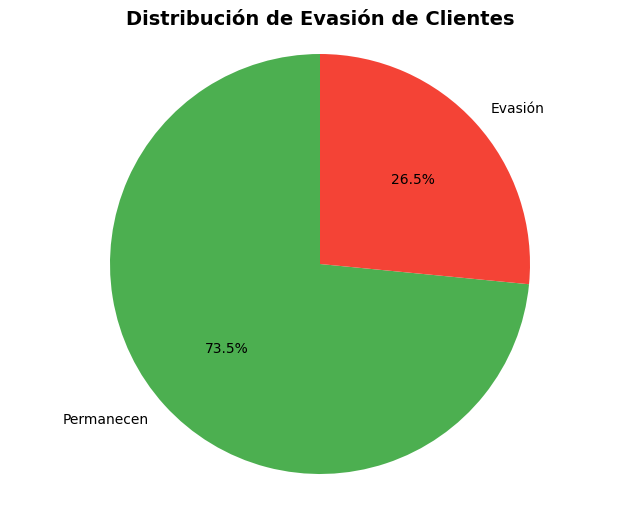

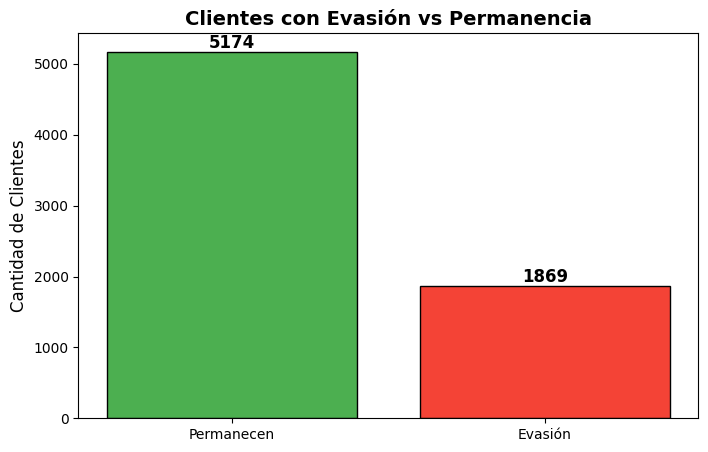

In [14]:
import matplotlib.pyplot as plt

print("=== DISTRIBUCIÓN DE EVASIÓN (CHURN) ===\n")

# Calcular distribución
distribucion = df_telecom_limpio['evasion'].value_counts()
porcentajes = df_telecom_limpio['evasion'].value_counts(normalize=True) * 100

print("Clientes que NO se dieron de baja (0):", distribucion[0])
print("Clientes que SÍ se dieron de baja (1):", distribucion[1])
print(f"\nTasa de evasión: {porcentajes[1]:.2f}%")

# Gráfico de pastel
plt.figure(figsize=(8, 6))
colores = ['#4CAF50', '#F44336']
etiquetas = ['Permanecen', 'Evasión']
plt.pie(distribucion, labels=etiquetas, colors=colores, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Evasión de Clientes', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

# Gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(etiquetas, distribucion, color=colores, edgecolor='black')
plt.title('Clientes con Evasión vs Permanencia', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Clientes', fontsize=12)
for i, v in enumerate(distribucion):
    plt.text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')
plt.show()

=== RECUENTO DE EVASIÓN POR VARIABLES CATEGÓRICAS ===


📊 GENERO:

Conteo:
evasion   0.0  1.0
genero            
Female   2549  939
Male     2625  930

Porcentaje por fila:
evasion    0.0    1.0
genero               
Female   73.08  26.92
Male     73.84  26.16

📊 TIPO_CONTRATO:

Conteo:
evasion          0.0   1.0
tipo_contrato             
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Porcentaje por fila:
evasion           0.0    1.0
tipo_contrato               
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83

📊 METODO_PAGO:

Conteo:
evasion                     0.0   1.0
metodo_pago                          
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308

Porcentaje por fila:
evasion                      0.0    1.0
metodo_pago                            
Bank transfer (automatic)  83.29  16.71
Credit card (au

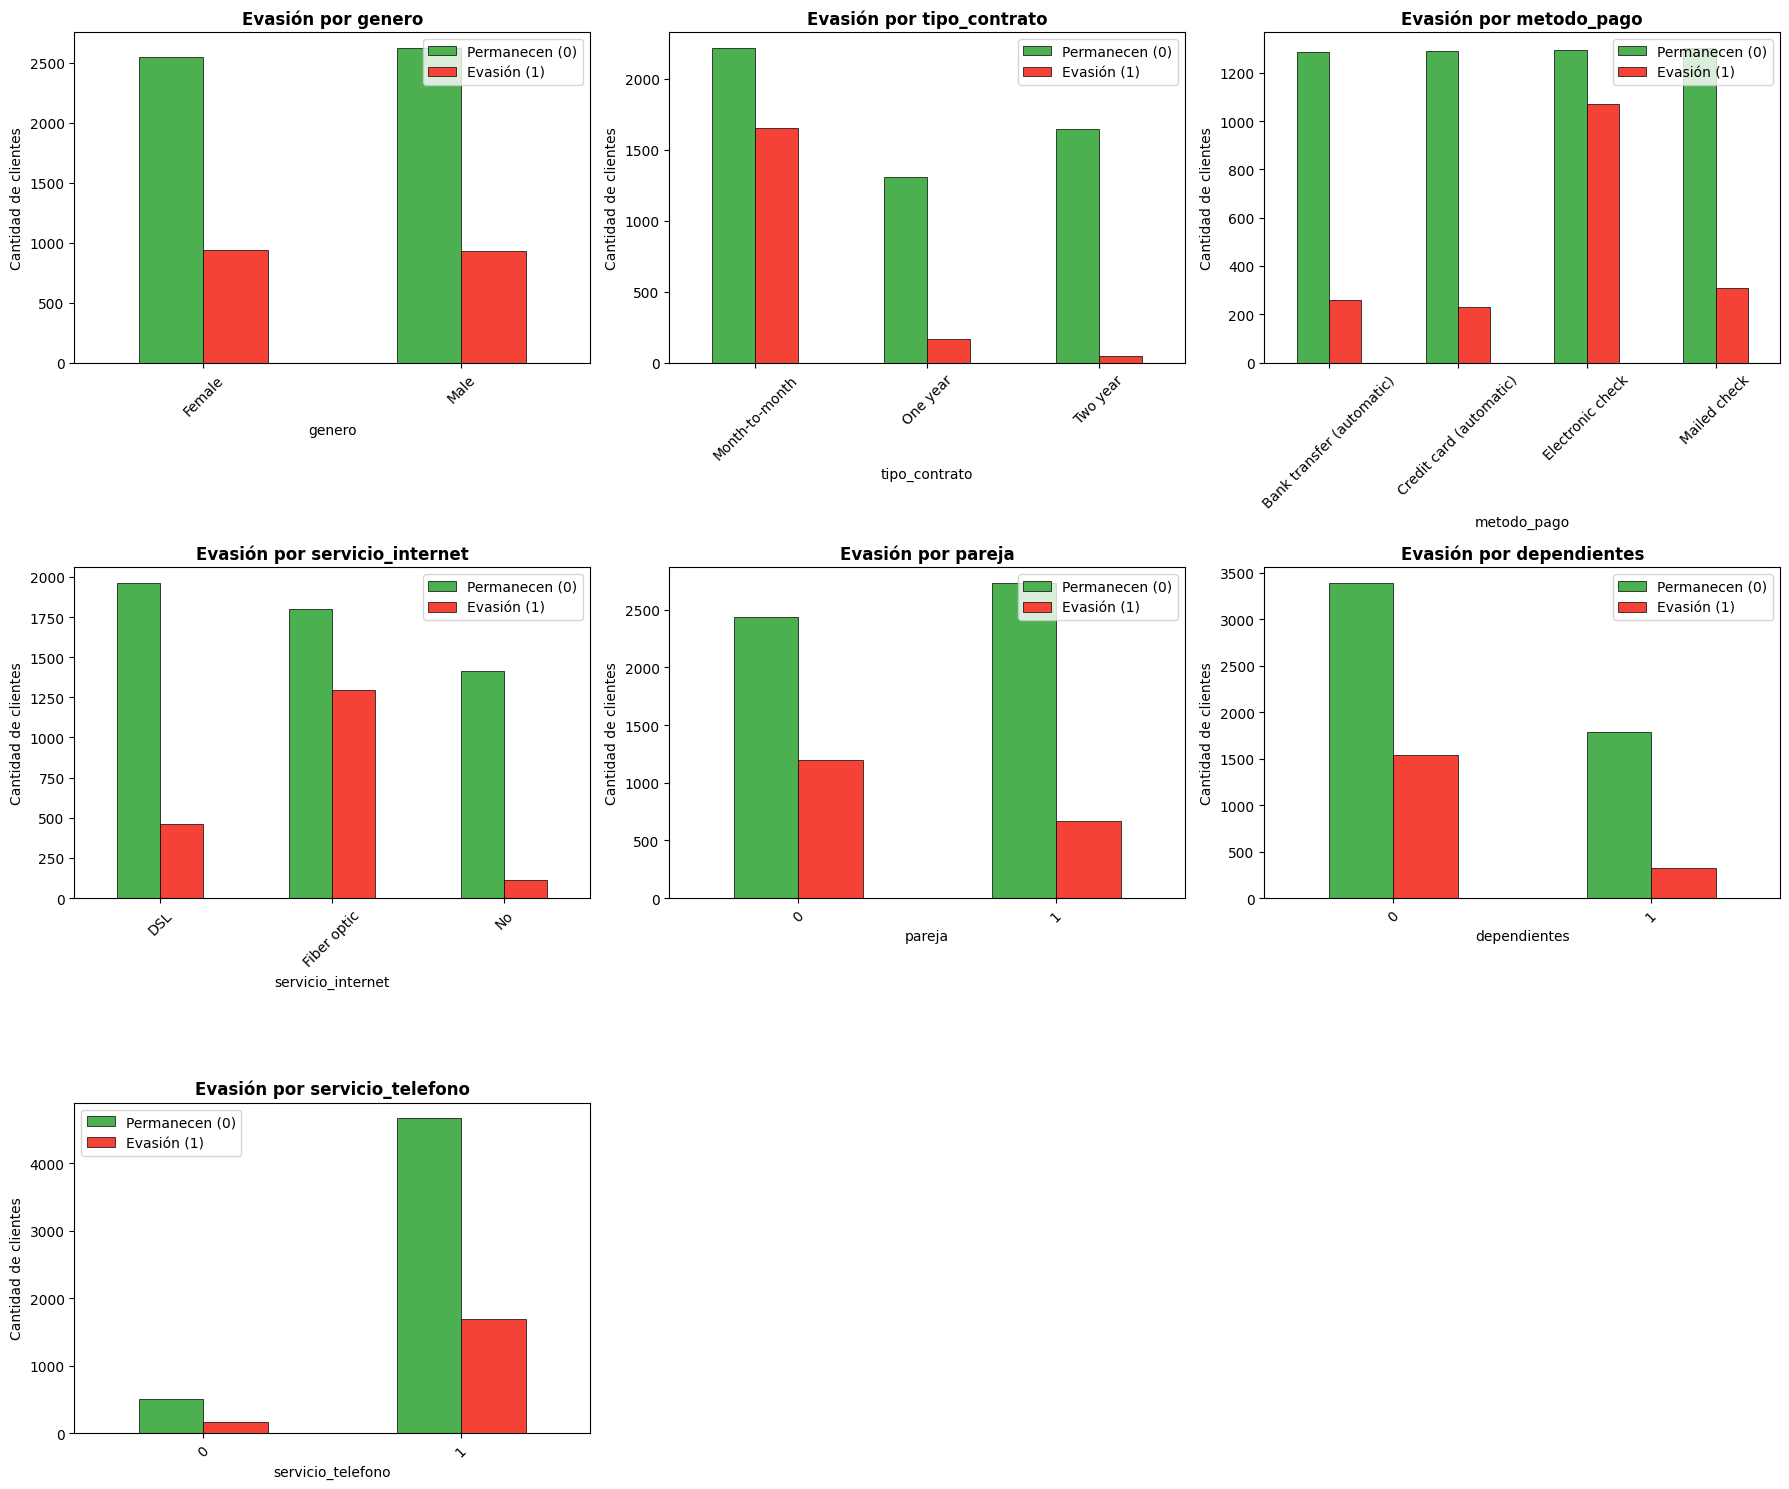


=== CONCLUSIONES RÁPIDAS ===

🔍 tipo_contrato: Diferencia significativa de 39.9% en evasión
   Mayor evasión: Month-to-month (42.7%)
   Menor evasión: Two year (2.8%)

🔍 metodo_pago: Diferencia significativa de 30.0% en evasión
   Mayor evasión: Electronic check (45.3%)
   Menor evasión: Credit card (automatic) (15.2%)

🔍 servicio_internet: Diferencia significativa de 34.5% en evasión
   Mayor evasión: Fiber optic (41.9%)
   Menor evasión: No (7.4%)

🔍 dependientes: Diferencia significativa de 15.8% en evasión
   Mayor evasión: 0 (31.3%)
   Menor evasión: 1 (15.5%)



In [15]:
import matplotlib.pyplot as plt
import pandas as pd

print("=== RECUENTO DE EVASIÓN POR VARIABLES CATEGÓRICAS ===\n")

# Seleccionar variables categóricas de interés
variables_categoricas = ['genero', 'tipo_contrato', 'metodo_pago', 'servicio_internet',
                         'pareja', 'dependientes', 'servicio_telefono']

# Configurar gráficos
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, var in enumerate(variables_categoricas):
    # Crear tabla cruzada
    cruzada = pd.crosstab(df_telecom_limpio[var], df_telecom_limpio['evasion'])
    cruzada_porcentaje = pd.crosstab(df_telecom_limpio[var], df_telecom_limpio['evasion'], normalize='index') * 100

    print(f"\n📊 {var.upper()}:")
    print("\nConteo:")
    print(cruzada)
    print("\nPorcentaje por fila:")
    print(cruzada_porcentaje.round(2))

    # Gráfico de barras apiladas
    cruzada.plot(kind='bar', ax=axes[idx], color=['#4CAF50', '#F44336'],
                 edgecolor='black', linewidth=0.5)
    axes[idx].set_title(f'Evasión por {var}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(var, fontsize=10)
    axes[idx].set_ylabel('Cantidad de clientes', fontsize=10)
    axes[idx].legend(['Permanecen (0)', 'Evasión (1)'])
    axes[idx].tick_params(axis='x', rotation=45)

# Eliminar subplot vacío
if len(variables_categoricas) < 9:
    for i in range(len(variables_categoricas), 9):
        fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Análisis de las variables más relevantes
print("\n=== CONCLUSIONES RÁPIDAS ===\n")

# Identificar variables con mayor diferencia en evasión
for var in variables_categoricas:
    cruzada = pd.crosstab(df_telecom_limpio[var], df_telecom_limpio['evasion'], normalize='index') * 100
    if 1 in cruzada.columns:
        max_evasion = cruzada[1].max()
        min_evasion = cruzada[1].min()
        diferencia = max_evasion - min_evasion
        if diferencia > 15:  # Si hay más de 15% de diferencia
            print(f"🔍 {var}: Diferencia significativa de {diferencia:.1f}% en evasión")
            print(f"   Mayor evasión: {cruzada[1].idxmax()} ({max_evasion:.1f}%)")
            print(f"   Menor evasión: {cruzada[1].idxmin()} ({min_evasion:.1f}%)")
            print()

=== EVASIÓN POR VARIABLES NUMÉRICAS ===


📊 ANTIGUEDAD_MESES:

✅ PERMANECEN:
   Media: 37.57
   Mediana: 38.00

❌ EVASIÓN:
   Media: 17.98
   Mediana: 10.00

📊 CARGO_MENSUAL:

✅ PERMANECEN:
   Media: 61.27
   Mediana: 64.43

❌ EVASIÓN:
   Media: 74.44
   Mediana: 79.65

📊 CARGO_TOTAL:

✅ PERMANECEN:
   Media: 2555.34
   Mediana: 1683.60

❌ EVASIÓN:
   Media: 1531.80
   Mediana: 703.55


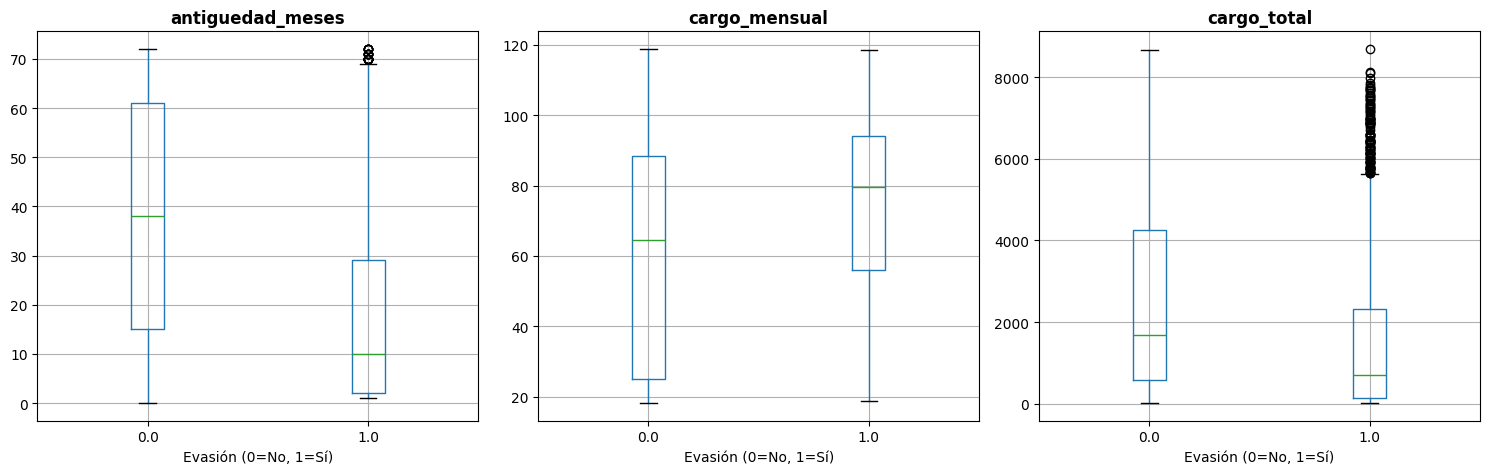

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=== EVASIÓN POR VARIABLES NUMÉRICAS ===\n")

# Variables numéricas con los nombres actualizados
numericas = ['antiguedad_meses', 'cargo_mensual', 'cargo_total']

# Asegurar que sean numéricas
for var in numericas:
    df_telecom_limpio[var] = pd.to_numeric(df_telecom_limpio[var], errors='coerce')

# Estadísticas comparativas
for var in numericas:
    print(f"\n📊 {var.upper()}:")

    # Clientes que NO cancelaron (evasión = 0)
    no_evasion = df_telecom_limpio[df_telecom_limpio['evasion'] == 0][var].dropna()
    print(f"\n✅ PERMANECEN:")
    print(f"   Media: {no_evasion.mean():.2f}")
    print(f"   Mediana: {no_evasion.median():.2f}")

    # Clientes que SI cancelaron (evasión = 1)
    si_evasion = df_telecom_limpio[df_telecom_limpio['evasion'] == 1][var].dropna()
    print(f"\n❌ EVASIÓN:")
    print(f"   Media: {si_evasion.mean():.2f}")
    print(f"   Mediana: {si_evasion.median():.2f}")

# Gráfico boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, var in enumerate(numericas):
    df_telecom_limpio.boxplot(column=var, by='evasion', ax=axes[idx])
    axes[idx].set_title(f'{var}', fontweight='bold')
    axes[idx].set_xlabel('Evasión (0=No, 1=Sí)')
plt.suptitle('')
plt.tight_layout()
plt.show()

#📄Informe final

# 📊 INFORME DE ANÁLISIS DE EVASIÓN (CHURN) - TELECOM X

## 🔹 1. INTRODUCCIÓN
**Objetivo:** Analizar factores asociados a la evasión de clientes (churn) para identificar perfiles de riesgo y proponer estrategias de retención.

**Contexto:** Tasa de evasión actual: **26.54%** (1,869 de 7,263 clientes)

---

## 🔹 2. LIMPIEZA Y TRATAMIENTO DE DATOS
- ✅ No se encontraron valores ausentes
- ✅ No se encontraron registros duplicados
- ✅ Columnas renombradas para mejor comprensión
- ✅ Variables binarias (Sí/No) convertidas a 1/0
- ✅ Nueva columna: Cuentas_Diarias (cargo_mensual/30)

---

## 🔹 3. ANÁLISIS EXPLORATORIO

### 3.1 Variables categóricas (% de evasión)
| Variable | Mayor evasión | Menor evasión |
|----------|--------------|---------------|
| Tipo de contrato | Mensual: **42.7%** | 2 años: **2.8%** |
| Método de pago | Electronic check: **45.3%** | Tarjeta: **15.2%** |
| Servicio internet | Fibra óptica: **41.9%** | Sin internet: **7.4%** |
| Dependientes | Sin: 31.3% | Con: 15.5% |
| Pareja | Sin: 33.0% | Con: 19.7% |

### 3.2 Variables numéricas (promedios)
| Variable | Permanecen | Evasión | Conclusión |
|----------|------------|---------|------------|
| Antigüedad | 37.6 meses | **18.0 meses** | Los que se van tienen la mitad de antigüedad |
| Cargo mensual | $61.27 | **$74.44** | Los que se van pagan más |
| Cargo total | $2,555 | **$1,532** | Los activos pagan más acumulado |

---

## 🔹 4. PERFILES IDENTIFICADOS

### 🚨 ALTO RIESGO DE EVASIÓN
- Contrato **mensual**
- Pago con **Electronic check**
- Internet **fibra óptica**
- Antigüedad **< 18 meses**
- **Sin** pareja ni dependientes

### ✅ BAJO RIESGO DE EVASIÓN
- Contrato **2 años**
- Pago automático (tarjeta/transferencia)
- Internet **DSL o sin internet**
- Antigüedad **> 37 meses**
- **Con** pareja y/o dependientes

---

## 🔹 5. RECOMENDACIONES

1. **Convertir contratos mensuales a anuales** con descuentos
2. **Revisar calidad del servicio de fibra óptica** (alta evasión)
3. **Programa especial para primeros 18 meses** (seguimiento)
4. **Incentivar métodos de pago automáticos** (descuentos)
5. **Alertas tempranas** para perfiles de alto riesgo
